`conda activate r_env_standr`

In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(dplyr)
    library(here)
    library(tibble)
    library(SCpubr)
    library(dittoSeq)
    library(stringr)
    library(data.table)
    library(tidyverse)
    library(patchwork) 
    library(RColorBrewer) 
    library(ggplot2)
    library(dplyr)
    library(reticulate)
    library(jsonlite)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [2]:
use_condaenv('seacells')

In [3]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [16]:
rg <- subset(malignant, NMF == 'MP_4')
rg

An object of class Seurat 
19248 features across 37209 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, diffusion

In [18]:
MP_list = readRDS('nmf/data/robust_NMF_programs_malignant_nomt_noribo.rds')

In [19]:
core_MP <- MP_list[,c(1,6,10)]

In [20]:
for (i in 1:ncol(core_MP)) {
  gene_set <- as.data.frame(core_MP)[[i]]
  rg <- UCell::AddModuleScore_UCell(
    obj = rg,
    features = list(gene_set),
    ncores = 64,
    name = colnames(core_MP)[i]
  )
}

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C21ORF58”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C4ORF47”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C11ORF96”


In [29]:
library(mclust)

# helper: find the x where the two component posteriors cross
find_mix_thresh <- function(x){
  fit <- Mclust(x, G = 2)      # 2 components
  grid <- seq(min(x), max(x), length.out = 1000)
  post <- predict(fit, grid)$z # Nx2 matrix of posteriors
  # threshold = point where P(comp1)=P(comp2)
  grid[which.min(abs(post[,1] - post[,2]))]
}

th_mix_6  <- find_mix_thresh(rg$signature_1MP_6)
th_mix_10 <- find_mix_thresh(rg$signature_1MP_10)

Package 'mclust' version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.


Attaching package: ‘mclust’


The following object is masked from ‘package:purrr’:

    map




In [30]:
# classify
rg$call_mix <- ifelse(rg$signature_1MP_6  > th_mix_6 |
                      rg$signature_1MP_10 > th_mix_10,
                      "TE-associated","developmental-like")
table(rg$call_mix)


developmental-like      TE-associated 
             29923               7286 

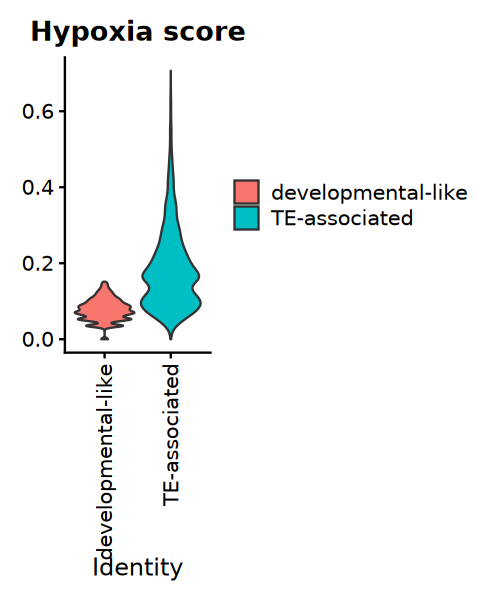

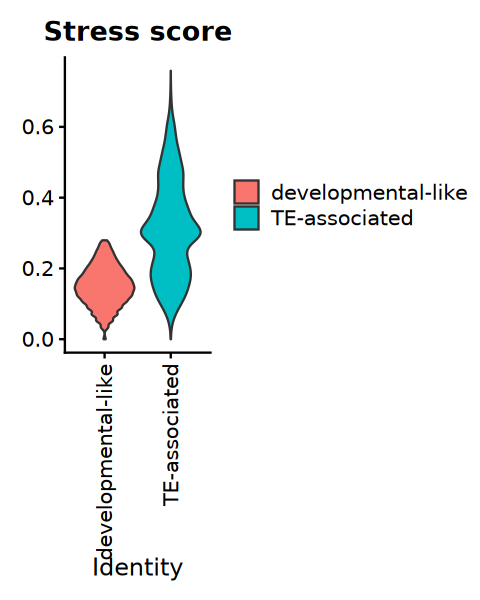

In [31]:
options(repr.plot.height =5, repr.plot.width = 4)
# add to the violin/density plots
VlnPlot(rg, features = c("signature_1MP_6"),
                        pt.size = 0,
        group.by = 'call_mix')+
  scale_x_discrete(guide = guide_axis(angle = 90)) +
  ggtitle("Hypoxia score")
VlnPlot(rg, features = c("signature_1MP_10"),
                        pt.size = 0,
        group.by = 'call_mix')+
  scale_x_discrete(guide = guide_axis(angle = 90))+
  ggtitle("Stress score")

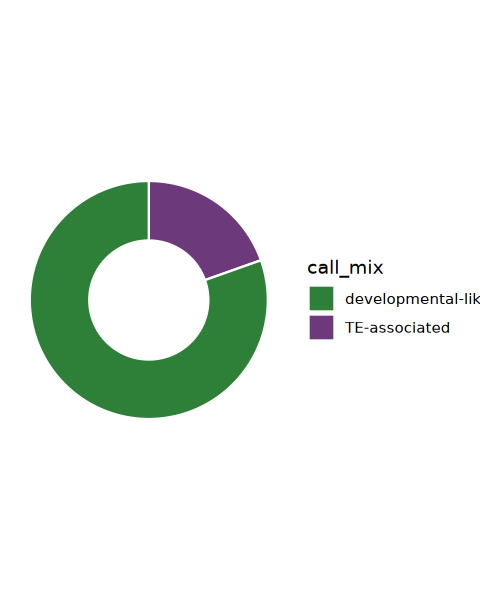

In [34]:
library(Seurat)
library(ggplot2)
library(dplyr)

df <- rg@meta.data %>%
  count(call_mix) %>%
  mutate(proportion = n / sum(n),
         label = paste0(call_mix, " (", round(proportion * 100, 1), "%)"))

ggplot(df, aes(x = 2, y = proportion, fill = call_mix)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar(theta = "y") +
  xlim(0.5, 2.5) + 
  theme_void() +
  theme(legend.position = "right") +
  # geom_text(aes(label = label), position = position_stack(vjust = 0.5)) +
  scale_fill_manual(values = c('#2e8039', '#6c397b'))

In [35]:
ggsave('figures/proportions_rg_subpopulations_donut_plot.pdf')

Saving 6.67 x 6.67 in image


In [37]:
library(readxl)
file_path <- "/projects/0/einf2548/cruiz/dmg/notebooks/nmf/data/Venkataramani_ Invasiveness_signature.xlsx"
data <- read_excel(file_path, sheet = "Tab 2-Supplementary Table 2a")
data

Gene,S24_statistic,S24_parameter,S24_p.value,S24-correlation coefficient estimate,S24_null.value,S24_alternative,S24_method,P3XX_statistic,P3XX_parameter,⋯,P3XX_alternative,P3XX_method,T269_statistic,T269_parameter,T269_p.value,T269-correlation coefficient estimate,T269_null.value,T269_alternative,T269_method,Direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
AC114730.3,-27.5361968,15627,4.913516e-163,-0.215118384,0,two.sided,Pearson's product-moment correlation,-13.971037,3013,⋯,two.sided,Pearson's product-moment correlation,-7.993750,17176,1.391466e-15,-0.06088119,0,two.sided,Pearson's product-moment correlation,Anticorrelated
ACAT2,26.3135178,15627,2.361662e-149,0.205980829,0,two.sided,Pearson's product-moment correlation,18.847910,3013,⋯,two.sided,Pearson's product-moment correlation,8.610422,17176,7.900615e-18,0.06555837,0,two.sided,Pearson's product-moment correlation,Correlated
ACTB,30.6877422,15627,7.185270e-201,0.238407673,0,two.sided,Pearson's product-moment correlation,19.693504,3013,⋯,two.sided,Pearson's product-moment correlation,28.315011,17176,2.017107e-172,0.21117825,0,two.sided,Pearson's product-moment correlation,Correlated
ANAPC11,39.2248617,15627,0.000000e+00,0.299386392,0,two.sided,Pearson's product-moment correlation,23.380055,3013,⋯,two.sided,Pearson's product-moment correlation,13.202385,17176,1.325460e-39,0.10023026,0,two.sided,Pearson's product-moment correlation,Correlated
ANXA2,69.2794039,15627,0.000000e+00,0.484736496,0,two.sided,Pearson's product-moment correlation,1.471536,3013,⋯,two.sided,Pearson's product-moment correlation,31.274489,17176,7.163232e-209,0.23211486,0,two.sided,Pearson's product-moment correlation,Correlated
AP2S1,31.2547087,15627,4.612903e-208,0.242555410,0,two.sided,Pearson's product-moment correlation,13.519309,3013,⋯,two.sided,Pearson's product-moment correlation,9.552745,17176,1.428953e-21,0.07269701,0,two.sided,Pearson's product-moment correlation,Correlated
ASCL1,-35.0028125,15627,1.738642e-258,-0.269634015,0,two.sided,Pearson's product-moment correlation,-11.623998,3013,⋯,two.sided,Pearson's product-moment correlation,-18.456694,17176,2.464027e-75,-0.13945317,0,two.sided,Pearson's product-moment correlation,Anticorrelated
ASPM,-7.9323265,15627,2.295602e-15,-0.063327186,0,two.sided,Pearson's product-moment correlation,13.879732,3013,⋯,two.sided,Pearson's product-moment correlation,33.972231,17176,6.804857e-245,0.25092360,0,two.sided,Pearson's product-moment correlation,Correlated
ATF3,33.9898968,15627,2.254784e-244,0.262375897,0,two.sided,Pearson's product-moment correlation,5.873370,3013,⋯,two.sided,Pearson's product-moment correlation,31.123962,17176,6.127660e-207,0.23105744,0,two.sided,Pearson's product-moment correlation,Correlated


In [38]:
invasiveness_sig <- list(data$Gene)
invasiveness_sig

[[1]]
  [1] "AC114730.3"  "ACAT2"       "ACTB"        "ANAPC11"     "ANXA2"      
  [6] "AP2S1"       "ASCL1"       "ASPM"        "ATF3"        "ATP1B3"     
 [11] "AURKA"       "AURKAIP1"    "AURKB"       "B2M"         "BCAN"       
 [16] "BCL7C"       "BIRC5"       "BTG1"        "BUB1"        "BUD31"      
 [21] "CALM1"       "CALM2"       "CASC5"       "CCDC109B"    "CCNA2"      
 [26] "CDCA3"       "CDK1"        "CDKN3"       "CENPA"       "CENPF"      
 [31] "CENPK"       "CFL1"        "CHCHD2"      "CHCHD3"      "CKAP2"      
 [36] "CKS1B"       "CLIC1"       "CLU"         "CNN3"        "COPRS"      
 [41] "COX5A"       "COX8A"       "CRYAB"       "CTNNAL1"     "CYR61"      
 [46] "DCX"         "DLGAP5"      "DLL1"        "DLL3"        "DNAJB1"     
 [51] "DNPH1"       "DTYMK"       "ECI1"        "EEF1B2"      "ETFB"       
 [56] "ETV1"        "FAM64A"      "FAM83D"      "FBXO5"       "FDPS"       
 [61] "FIBP"        "GAPDH"       "GFAP"        "GNB2"        "GPX4"       
 [66] "GSTP1"       "GTSE1"       "H2AFZ"       "HES6"        "HINT1"      
 [71] "HINT2"       "HIST1H4C"    "HJURP"       "HMGB2"       "HOPX"       
 [76] "ITGB1BP1"    "KCNQ1OT1"    "KIAA0101"    "KIF20A"      "KIF23"      
 [81] "KIF2C"       "KIFC1"       "KPNA2"       "LINC00152"   "LMNB1"      
 [86] "LRRN1"       "LSMD1"       "MAD2L1"      "MALAT1"      "MANF"       
 [91] "MARCKSL1"    "MEA1"        "MFNG"        "MIR4435-1HG" "MKI67"      
 [96] "MRPL37"      "MT-ND3"      "MT2A"        "MXD3"        "MYC"        
[101] "MZT2B"       "NCAPG"       "NDC80"       "NDUFA4"      "NDUFA6"     
[106] "NDUFS8"      "NEK2"        "NEU4"        "NGFRAP1"     "NMB"        
[111] "NUF2"        "NUSAP1"      "OLIG1"       "PBK"         "PCOLCE"     
[116] "PFN1"        "PHF19"       "PHPT1"       "PKM"         "POLR2I"     
[121] "PPIA"        "PRC1"        "PRR24"       "PSMA7"       "PSMB3"      
[126] "PSME2"       "PTN"         "PTTG1"       "PXMP2"       "RACGAP1"    
[131] "RBX1"        "RDX"         "RRM2"        "SGOL1"       "SGOL2"      
[136] "SHD"         "SHMT2"       "SIVA1"       "SLC25A5"     "SMC4"       
[141] "SOCS3"       "SOX4"        "SPARC"       "SPC25"       "SSBP4"      
[146] "STK17A"      "TAGLN2"      "TCF12"       "TCTEX1D2"    "TECR"       
[151] "TK1"         "TMEM147"     "TMEM54"      "TNFRSF12A"   "TNK2"       
[156] "TOP2A"       "TPI1"        "TPX2"        "TUBA1B"      "TUBA1C"     
[161] "TUBB2A"      "TUBB6"       "UBE2C"       "UBE2T"       "UQCC2"      
[166] "UQCR10"      "UQCRC1"      "UQCRQ"       "VIM"         "VMP1"       
[171] "ZFP36"       "ZWINT"

In [39]:
rg <- UCell::AddModuleScore_UCell(
    obj = rg,
    features = invasiveness_sig,
    ncores = 8,
    name = 'invasiveness'
    )

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* AC114730.3,CASC5,CCDC109B,CYR61,FAM64A,KCNQ1OT1,KIAA0101,LINC00152,LSMD1,MALAT1,MIR4435-1HG,NGFRAP1,PRR24,SGOL1,SGOL2”


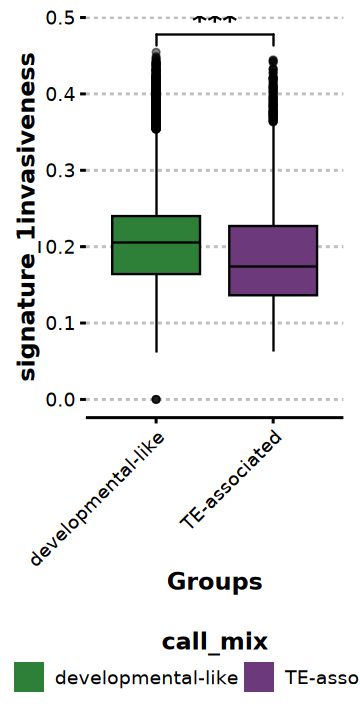

In [44]:
options(repr.plot.height = 6, repr.plot.width = 3)
SCpubr::do_BoxPlot(sample = rg,
                   colors.use = c("TE-associated"='#6c397b',"developmental-like"='#2e8039'),
                   feature = "signature_1invasiveness",
                   group.by = "call_mix",
                   use_test = TRUE,
                   map_signif_level = TRUE,
                   comparisons = list(c("TE-associated","developmental-like")
                                   ),
                   order = TRUE)

In [46]:
ggsave('figures/boxplot_invasivity_rg_subpopulations.pdf', height = 5, width = 2)

### GO

In [47]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(dplyr)



clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:purrr’:

    simplify


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked fr

In [48]:
# Assuming 'call_mix' has the two groups of interest
markers <- FindMarkers(rg, 
                       ident.1 = "TE-associated", 
                       ident.2 = "developmental-like", 
                       group.by = "call_mix", 
                       logfc.threshold = 0, 
                       min.pct = 0.1)

In [49]:
markers$gene <- rownames(markers)

up_TE <- markers %>%
  filter(avg_log2FC > 2, p_val_adj < 0.001) %>%
  pull(gene)

up_dev <- markers %>%
  filter(avg_log2FC < 2, p_val_adj < 0.001) %>%
  pull(gene)

In [52]:
# For TR-associated
entrez_TE <- bitr(up_TE, fromType="SYMBOL", toType="ENTREZID", OrgDb=org.Hs.eg.db)

# For developmental-like
entrez_dev <- bitr(up_dev, fromType="SYMBOL", toType="ENTREZID", OrgDb=org.Hs.eg.db)

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(up_TE, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“1.76% of input gene IDs are fail to map...”
'select()' returned 1:many mapping between keys and columns

Warning message in bitr(up_dev, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“2.08% of input gene IDs are fail to map...”


In [53]:
ego_TE <- enrichGO(gene         = entrez_TE$ENTREZID,
                   OrgDb        = org.Hs.eg.db,
                   ont          = "BP",
                   pAdjustMethod = "BH",
                   pvalueCutoff = 0.05,
                   readable     = TRUE)

ego_dev <- enrichGO(gene         = entrez_dev$ENTREZID,
                    OrgDb        = org.Hs.eg.db,
                    ont          = "BP",
                    pAdjustMethod = "BH",
                    pvalueCutoff = 0.05,
                    readable     = TRUE)

In [59]:
library(enrichplot)
library(GOSemSim)

GOSemSim v2.28.1  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use GOSemSim in published research, please cite:
- Guangchuang Yu. Gene Ontology Semantic Similarity Analysis Using GOSemSim. In: Kidder B. (eds) Stem Cell Transcriptional Networks. Methods in Molecular Biology, 2020, 2117:207-215. Humana, New York, NY. doi:10.1007/978-1-0716-0301-7_11
- Guangchuang Yu, Fei Li, Yide Qin, Xiaochen Bo, Yibo Wu, Shengqi Wang. GOSemSim: an R package for measuring semantic similarity among GO terms and gene products Bioinformatics 2010, 26(7):976-978. doi:10.1093/bioinformatics/btq064





preparing gene to GO mapping data...

preparing IC data...

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invail

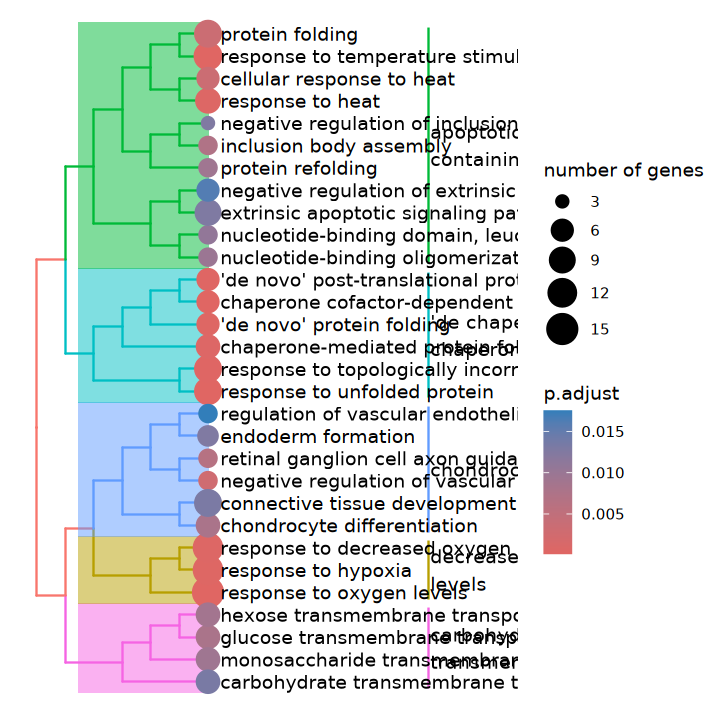

In [60]:
d <- godata('org.Hs.eg.db', ont="BP")
ego2 <- pairwise_termsim(ego_TE, semData = d)
treeplot(ego2)

Warning message in treeplot.enrichResult(x, ...):
“Use 'cluster.params = list(n = your_value)' instead of 'nCluster'.
 The nCluster parameter will be removed in the next version.”
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.



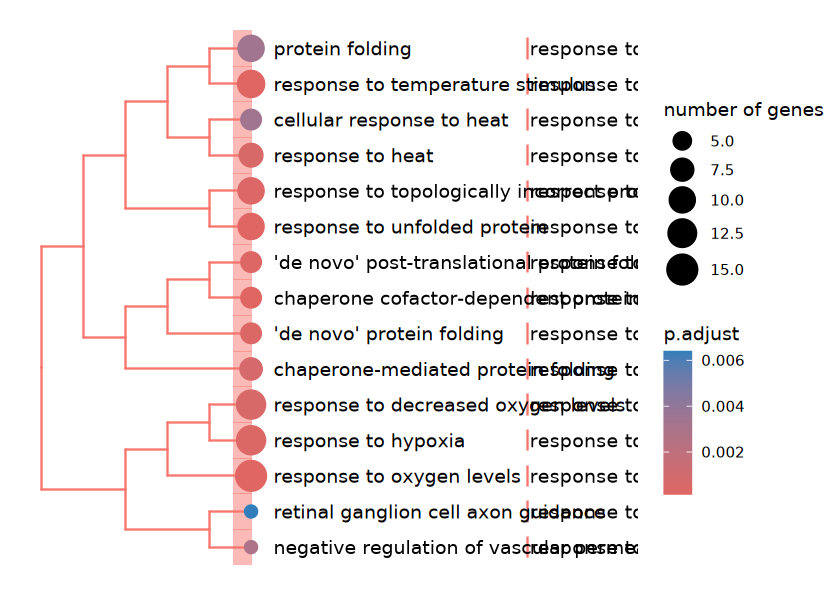

In [70]:
options(repr.plot.height = 5, repr.plot.width = 7)
treeplot(ego2, showCategory = 15, nCluster = 1)

In [71]:
ggsave('figures/go_analysis_rg_te_associated.pdf', width = 7, height = 5)

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Inva

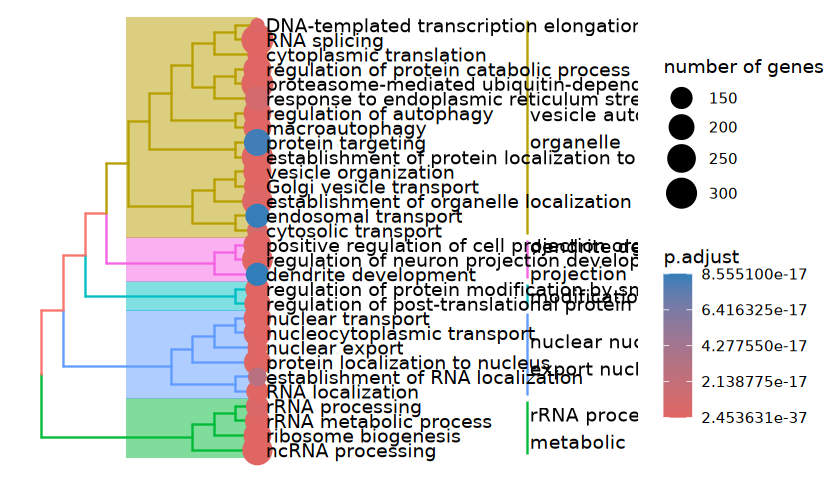

In [66]:
ego3 <- pairwise_termsim(ego_dev, semData = d)
treeplot(ego3)

Warning message in treeplot.enrichResult(x, ...):
“Use 'cluster.params = list(n = your_value)' instead of 'nCluster'.
 The nCluster parameter will be removed in the next version.”
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.



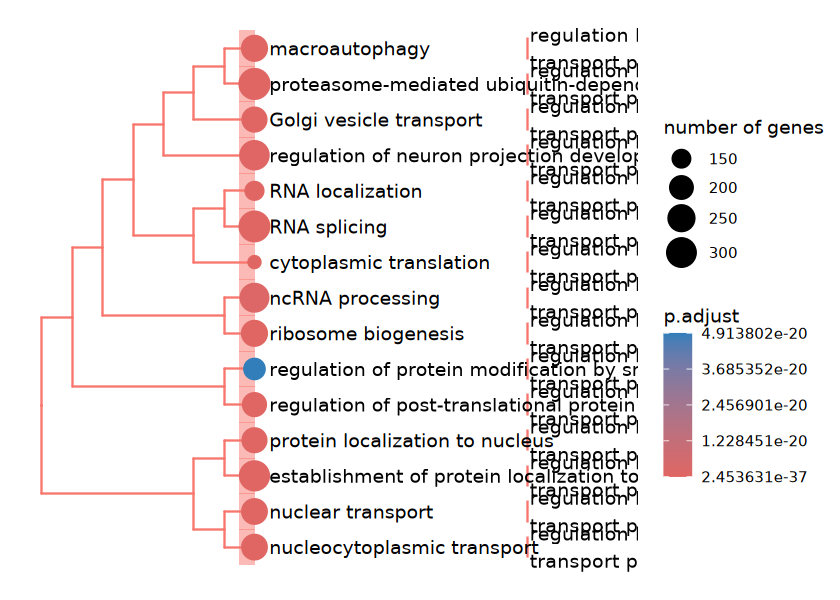

In [72]:
options(repr.plot.height = 5, repr.plot.width = 7)
treeplot(ego3, showCategory = 15, nCluster = 1)

In [73]:
ggsave('figures/go_analysis_rg_dev_like.pdf', width = 7, height = 5)